In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Load dataset
df = pd.read_csv("salary_data.csv")

In [5]:
# Convert Salary into a binary classification target (e.g., above/below median salary)
threshold = df['Salary'].median()
df['Salary_Class'] = np.where(df['Salary'] >= threshold, 1, 0)  # 1 = High, 0 = Low

In [6]:
# Define features and target variable
X = df[['YearsExperience']]
y = df['Salary_Class']

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
# Make predictions
y_pred = model.predict(X_test)

In [10]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [11]:
print(f'Accuracy: {accuracy:.4f}')
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.8333
Confusion Matrix:
 [[2 0]
 [1 3]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



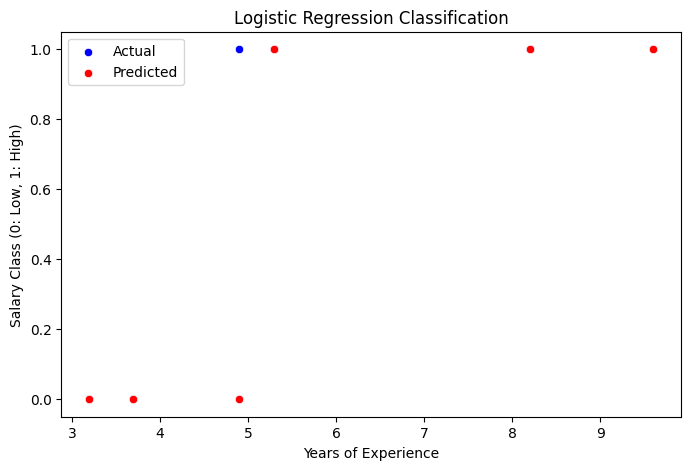

In [12]:
# Visualize decision boundary
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test['YearsExperience'], y=y_test, color='blue', label='Actual')
sns.scatterplot(x=X_test['YearsExperience'], y=y_pred, color='red', label='Predicted')
plt.xlabel("Years of Experience")
plt.ylabel("Salary Class (0: Low, 1: High)")
plt.title("Logistic Regression Classification")
plt.legend()
plt.show()

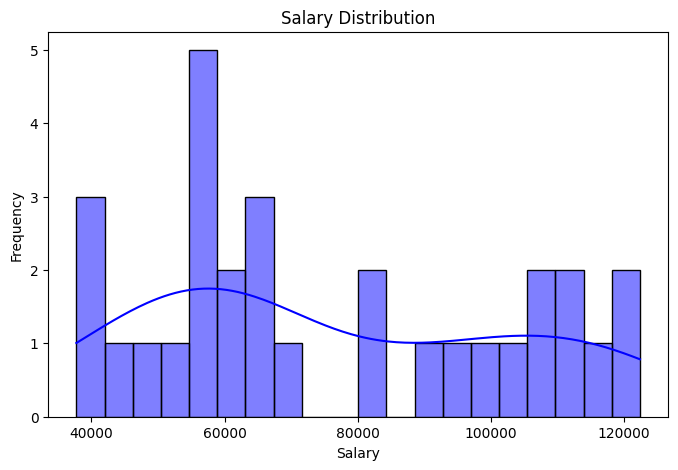

In [13]:
# 1. Salary Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary'], bins=20, kde=True, color='blue')
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution")
plt.show()

C:\Users\aarab\AppData\Local\Temp\ipykernel_14788\1793625732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Salary_Class'], palette=['red', 'green'])


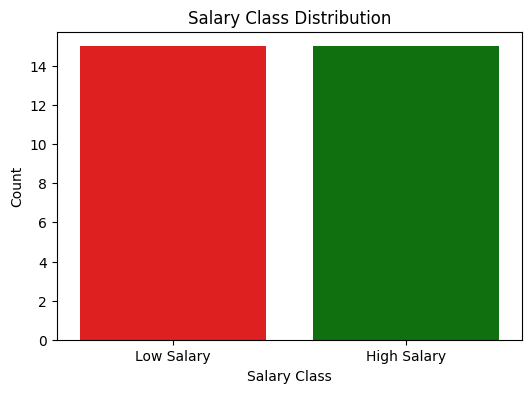

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Salary_Class'], palette=['red', 'green'])
plt.xticks(ticks=[0, 1], labels=['Low Salary', 'High Salary'])
plt.xlabel("Salary Class")
plt.ylabel("Count")
plt.title("Salary Class Distribution")
plt.show()